# Maximizing Revenue for Taxi Cab Drivers through Payment Type Analysis

# Problem Statement
In the fast-moving taxi industry, increasing revenue is important for drivers and business growth. In this project, we use data to check whether the payment method (card or cash) is related to the total fare amount. We want to see if customers who pay by card and those who pay by cash have different average fares.

# Objective
The main goal of this project is to compare the average total fare between card and cash payments using descriptive statistics and hypothesis testing. We aim to determine whether the difference in mean fares between the two payment methods is statistically significant and to understand whether trip distance may influence this difference.


# Research Question
Is there a statistically significant difference in the average total fare between card and cash payments?

# Imports
We start by importing all the essential Python libraries for data analysis, visualization, and hypothesis testing.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st
import warnings 
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("yellow_tripdata_2020-01 (1).csv")
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.20,1.0,N,238,239,1.0,6.00,3.00,0.5,1.47,0.00,0.3,11.27,2.5
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.20,1.0,N,239,238,1.0,7.00,3.00,0.5,1.50,0.00,0.3,12.30,2.5
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.60,1.0,N,238,238,1.0,6.00,3.00,0.5,1.00,0.00,0.3,10.80,2.5
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.80,1.0,N,238,151,1.0,5.50,0.50,0.5,1.36,0.00,0.3,8.16,0.0
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.00,1.0,N,193,193,2.0,3.50,0.50,0.5,0.00,0.00,0.3,4.80,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6405003,NaN,2020-01-31 22:51:00,2020-01-31 23:22:00,NaN,3.24,NaN,NaN,237,234,NaN,17.59,2.75,0.5,0.00,0.00,0.3,21.14,0.0
6405004,NaN,2020-01-31 22:10:00,2020-01-31 23:26:00,NaN,22.13,NaN,NaN,259,45,NaN,46.67,2.75,0.5,0.00,12.24,0.3,62.46,0.0
6405005,NaN,2020-01-31 22:50:07,2020-01-31 23:17:57,NaN,10.51,NaN,NaN,137,169,NaN,48.85,2.75,0.0,0.00,0.00,0.3,51.90,0.0
6405006,NaN,2020-01-31 22:25:53,2020-01-31 22:48:32,NaN,5.49,NaN,NaN,50,42,NaN,27.17,2.75,0.0,0.00,0.00,0.3,30.22,0.0


In [4]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.0,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0


In [5]:
df.shape

(6405008, 18)

In [6]:
df.dtypes

VendorID                 float64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count          float64
trip_distance            float64
RatecodeID               float64
store_and_fwd_flag        object
PULocationID               int64
DOLocationID               int64
payment_type             float64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
congestion_surcharge     float64
dtype: object

In [7]:
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

In [8]:
df.dtypes

VendorID                        float64
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                    float64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
dtype: object

In [9]:
df["duration"] = df["tpep_dropoff_datetime"]-df["tpep_pickup_datetime"]
df["duration"] = df["duration"].dt.total_seconds()/60

In [10]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,duration
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5,4.800000
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5,7.416667
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5,6.183333
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0,4.850000
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.0,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0,2.300000


In [11]:
df =  df[["passenger_count","payment_type","fare_amount","trip_distance","duration"]]
df

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1.0,1.0,6.00,1.20,4.800000
1,1.0,1.0,7.00,1.20,7.416667
2,1.0,1.0,6.00,0.60,6.183333
3,1.0,1.0,5.50,0.80,4.850000
4,1.0,2.0,3.50,0.00,2.300000
...,...,...,...,...,...
6405003,NaN,NaN,17.59,3.24,31.000000
6405004,NaN,NaN,46.67,22.13,76.000000
6405005,NaN,NaN,48.85,10.51,27.833333
6405006,NaN,NaN,27.17,5.49,22.650000


In [12]:
df.isnull().sum()

passenger_count    65441
payment_type       65441
fare_amount            0
trip_distance          0
duration               0
dtype: int64

In [13]:
 (65441/len(df))*100

1.021716132126611

In [14]:
df.dropna(inplace = True)

In [15]:
df.isnull().sum()

passenger_count    0
payment_type       0
fare_amount        0
trip_distance      0
duration           0
dtype: int64

In [16]:
df["passenger_count"] = df["passenger_count"].astype("int64")
df["payment_type"] = df["payment_type"].astype("int64")

In [17]:
df[df.duplicated()]

,passenger_count,payment_type,fare_amount,trip_distance,duration
2056,1,2,7.0,0.00,0.000000
2441,1,1,52.0,0.00,0.200000
2446,2,1,9.5,1.70,13.066667
2465,1,1,4.0,0.40,3.083333
3344,1,1,6.0,1.20,5.350000
...,...,...,...,...,...
6339558,1,2,8.0,1.63,8.800000
6339559,1,1,8.5,1.81,8.016667
6339560,1,2,6.5,0.98,6.900000
6339562,1,1,11.0,2.10,14.233333


In [18]:
df.drop_duplicates(inplace = True )

In [19]:
df["passenger_count"].value_counts(normalize = True)

passenger_count
1    0.581981
2    0.190350
3    0.066360
5    0.062937
6    0.039272
4    0.036046
0    0.023033
7    0.000009
9    0.000006
8    0.000006
Name: proportion, dtype: float64

In [20]:
df["payment_type"].value_counts(normalize = True) 

payment_type
1    6.782670e-01
2    3.075731e-01
3    8.721480e-03
4    5.438084e-03
5    3.324622e-07
Name: proportion, dtype: float64

In [21]:
df = df[df['payment_type']<3]
df = df[(df['passenger_count']>0) & (df['passenger_count']<6)]


In [22]:
df.shape

(2780283, 5)

In [23]:
df['payment_type'].replace([1, 2], ['card', 'cash'], inplace = True)
df

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1,card,6.0,1.20,4.800000
1,1,card,7.0,1.20,7.416667
2,1,card,6.0,0.60,6.183333
3,1,card,5.5,0.80,4.850000
4,1,cash,3.5,0.00,2.300000
...,...,...,...,...,...
6339555,3,card,10.0,2.09,14.800000
6339561,1,card,17.5,4.11,21.500000
6339563,1,card,13.0,2.13,19.000000
6339564,1,card,12.5,2.55,16.283333


In [24]:
df.describe()

,passenger_count,fare_amount,trip_distance,duration
count,2.780283e+06,2.780283e+06,2.780283e+06,2.780283e+06
mean,1.733386e+00,1.780567e+01,4.536729e+00,2.415478e+01
std,1.176652e+00,1.506997e+01,4.895890e+00,9.260031e+01
min,1.000000e+00,-5.000000e+02,-2.218000e+01,-2.770367e+03
25%,1.000000e+00,9.000000e+00,1.500000e+00,9.883333e+00
50%,1.000000e+00,1.300000e+01,2.730000e+00,1.573333e+01
75%,2.000000e+00,2.100000e+01,5.470000e+00,2.336667e+01
max,5.000000e+00,4.265000e+03,2.628800e+02,8.525117e+03


# Removing Invalid and Outlier Values
Filtering out negative or zero values and removing extreme outliers using the IQR method.

In [25]:
df = df[df['fare_amount']>0]
df = df[df['trip_distance']>0]
df = df[df['duration']>0]

In [26]:
df

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1,card,6.0,1.20,4.800000
1,1,card,7.0,1.20,7.416667
2,1,card,6.0,0.60,6.183333
3,1,card,5.5,0.80,4.850000
5,1,cash,2.5,0.03,0.883333
...,...,...,...,...,...
6339550,4,card,10.5,2.40,12.383333
6339555,3,card,10.0,2.09,14.800000
6339561,1,card,17.5,4.11,21.500000
6339563,1,card,13.0,2.13,19.000000


{'whiskers': [<matplotlib.lines.Line2D at 0x21e9b36ce10>,
 'caps': [<matplotlib.lines.Line2D at 0x21e9b36d090>,
 'boxes': [<matplotlib.lines.Line2D at 0x21e9b358b90>],
 'medians': [<matplotlib.lines.Line2D at 0x21e9b36d310>],
 'fliers': [<matplotlib.lines.Line2D at 0x21e9b36d450>],
 'means': []}

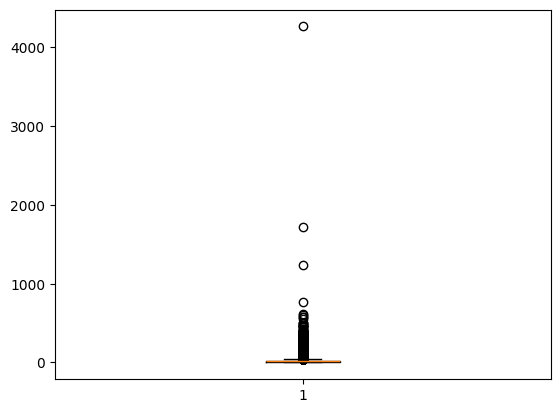

In [27]:
 plt.boxplot(df['fare_amount'])


In [28]:
for col in ['fare_amount', 'trip_distance', 'duration']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr


    df = df[(df[col]>=lower_bound) & (df[col]<=upper_bound)]

In [29]:
df

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1,card,6.0,1.20,4.800000
1,1,card,7.0,1.20,7.416667
2,1,card,6.0,0.60,6.183333
3,1,card,5.5,0.80,4.850000
5,1,cash,2.5,0.03,0.883333
...,...,...,...,...,...
6339550,4,card,10.5,2.40,12.383333
6339555,3,card,10.0,2.09,14.800000
6339561,1,card,17.5,4.11,21.500000
6339563,1,card,13.0,2.13,19.000000


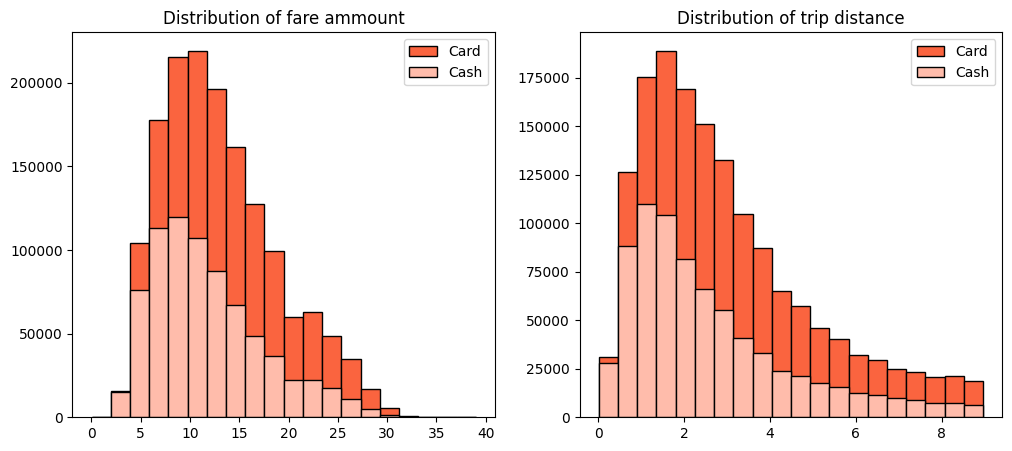

In [30]:
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
plt.title("Distribution of fare ammount")
plt.hist(df[df['payment_type']=='card']['fare_amount'], histtype= 'barstacked',bins = 20, edgecolor = 'k', color = "#FA643F", label = 'Card')
plt.hist(df[df['payment_type']=='cash']['fare_amount'], histtype= 'barstacked',bins = 20, edgecolor = 'k', color = "#FFBCAB", label = 'Cash')
plt.legend()

plt.subplot(1,2,2)
plt.title("Distribution of trip distance")
plt.hist(df[df['payment_type']=='card']['trip_distance'], histtype= 'barstacked',bins = 20, edgecolor = 'k', color = "#FA643F", label = 'Card')
plt.hist(df[df['payment_type']=='cash']['trip_distance'], histtype= 'barstacked',bins = 20, edgecolor = 'k', color = "#FFBCAB", label = 'Cash')
plt.legend()
plt.show()

In [31]:
df.groupby("payment_type").agg({'fare_amount': ['mean', 'std'], 'trip_distance': ['mean', 'std']})

fare_amount           trip_distance         
                    mean       std          mean      std
payment_type                                             
card           13.112493  5.849281      2.992237  1.99274
cash           11.758005  5.613038      2.602207  1.91372

# Payment Type Preference
Visualizing overall preference for card vs. cash payments using a pie chart.

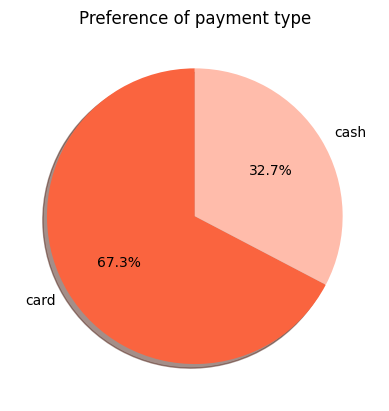

In [32]:
plt.title("Preference of payment type")
plt.pie(df['payment_type'].value_counts(normalize = True), labels = df['payment_type'].value_counts().index,
        startangle = 90, shadow = True, autopct = '%1.1f%%', colors = [ "#FA643F", "#FFBCAB"])
plt.show()

# Passenger Count Analysis
Calculating passenger count distribution for each payment type and deriving percentages.

In [33]:
passenger_count = df.groupby(['payment_type', 'passenger_count'])[['passenger_count']].count()
passenger_count.rename(columns={'passenger_count': 'count'}, inplace=True)
passenger_count = passenger_count.reset_index()

In [34]:
passenger_count['perc'] = (passenger_count['count'] / passenger_count['count'].sum()) * 100

In [35]:
passenger_count


,payment_type,passenger_count,count,perc
0,card,1,909245,39.568381
1,card,2,327661,14.259100
2,card,3,122412,5.327106
3,card,4,63676,2.771042
4,card,5,124045,5.398171
5,cash,1,460550,20.042143
6,cash,2,155472,6.765806
7,cash,3,54506,2.371984
8,cash,4,32715,1.423686
9,cash,5,47626,2.072581


# Stacked Bar Visualization
Creating a stacked horizontal bar chart to visualize passenger count distribution by payment type.

In [38]:
pivot_df = passenger_count.pivot(index='payment_type',
                                  columns='passenger_count',
                                  values='perc')



passenger_count,1,2,3,4,5
payment_type,,,,,
card,39.568381,14.259100,5.327106,2.771042,5.398171
cash,20.042143,6.765806,2.371984,1.423686,2.072581


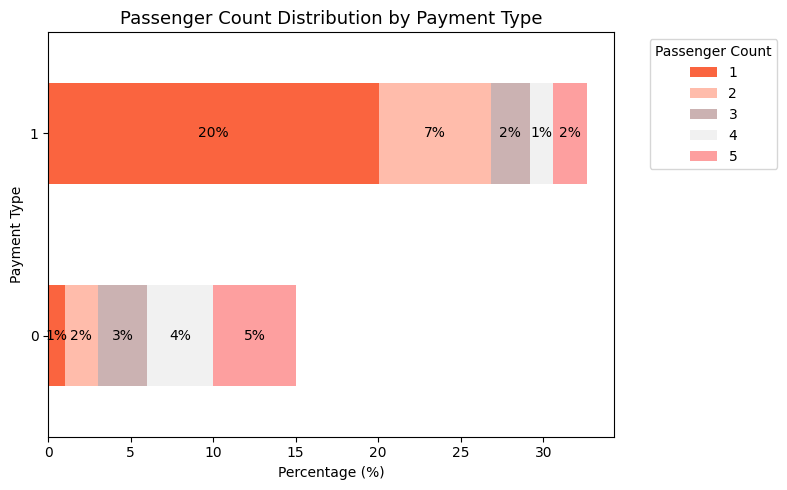

In [83]:
ax = pivot_df.plot(
    kind='barh',
    stacked=True,
    color=['#FA643F','#FFBCAB','#CBB2B2','#F1F1F1', '#FD9F9F'],
    figsize=(8,5)
)

#  Add percentage labels 
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        x, y = p.get_xy()
        ax.text(
            x + width/2,
            y + p.get_height()/2,
            f'{width:.0f}%',
            ha='center',
            va='center',
            fontsize=10,
            color='black'
        )

#  Titles and labels 
plt.title('Passenger Count Distribution by Payment Type', fontsize=13)
plt.xlabel('Percentage (%)')
plt.ylabel('Payment Type')
plt.legend(title='Passenger Count', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# Hypothesis Testing: Fare Amount
Performing a two-sample t-test to check if there is a significant difference in average fare amount between card and cash payments.

In [38]:
card_sample = df[df['payment_type']=='card']['fare_amount']
cash_sample = df[df['payment_type']=='cash']['fare_amount']

In [39]:
t_stats, p_value = st.ttest_ind(a = card_sample, b = cash_sample, equal_var = False)
print("P tastistic", t_stats, "P Value", p_value)

P tastistic 169.2111527245052 P Value 0.0


# Hypothesis Test Interpretation¶

In this project, we compared the average total fare between card and cash payments using descriptive statistics and a two-sample independent t-test.

The average fare for card payments was 13.11, while the average fare for cash payments was 11.76. The t-test results showed a t-statistic of 169.21 and a p-value close to 0.0, which is less than the significance level of 0.05. Therefore, we reject the null hypothesis and conclude that there is a statistically significant difference in average fares between card and cash payments.

However, we also observed that card users travel longer distances on average (2.99 miles) compared to cash users (2.60 miles). Since fare amount mainly depends on trip distance, the higher average fare for card payments is likely influenced by longer trips rather than payment method alone.

Therefore, although a significant difference exists, we cannot conclude that payment type directly causes higher fares. Further analysis controlling for trip distance would be required to confirm the independent effect of payment method.